In [7]:
import argparse
import datetime
import json
import random
import time
from pathlib import Path
import os
import numpy as np
import torch
from torch.utils.data import DataLoader
import datasets
import util.misc as utils
import datasets.samplers as samplers
from datasets import build_dataset, get_coco_api_from_dataset
from datasets.coco import make_coco_transforms
from datasets.torchvision_datasets.open_world import OWDetection
# from engine import evaluate, train_one_epoch, get_exemplar_replay
from models import build_model
import wandb

/workspace/.local/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'OWDETR': ('aeroplane', 'bicycle', 'bird', 'boat', 'bus', 'car', 'cat', 'cow', 'dog', 'horse', 'motorbike', 'sheep', 'train', 'elephant', 'bear', 'zebra', 'giraffe', 'truck', 'person', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'chair', 'diningtable', 'pottedplant', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'bed', 'toilet', 'sofa', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'tvmonitor', 'bottle', 'unknown'), 'TOWOD': ('aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable',

## Arguments setting

In [8]:
from dotmap import DotMap

args = DotMap(
    # main code
    frozen_weights=None,
    seed=0,
    device='cuda',
    data_root='data/OWOD',
    batch_size=2,
    num_workers=8,
    lr_linear_proj_names=['reference_points', 'sampling_offsets'],
    lr=2e-4,
    lr_backbone_names=["backbone.0"],
    lr_linear_proj_mult=2e-5,
    sgd=False,
    weight_decay=1e-4,    
    pretrain=None,
    freeze_prob_model=False,
    start_epoch=0,
    nc_epoch=0,
    clip_max_norm=0.1,
    
    # build_model
    num_classes=81,
    num_queries=100,
    num_feature_levels=4,
    aux_loss=True,
    with_box_refine=False,
    two_stage=False,
    masks=False,
    cls_loss_coef=2,
    bbox_loss_coef=5,
    giou_loss_coef=2,
    # obj_loss_coef=1, # duplicated
    # mask_loss_coef=,
    # dice_loss_coef=,
    dec_layers=6,
    hidden_dim=256,
    focal_alpha=0.25,
    # obj_temp=1, # duplicated
    # dataset_file=,
    
    # build_backbone
    lr_backbone=2e-5,
    backbone='dino_resnet50',
    dilation=False,
    position_embedding='sine',
    
    # build_deforamble_transformer
    nheads=8,
    enc_layers=6,
    dim_feedforward=1024,
    dropout=0.1,
    dec_n_points=4,
    enc_n_points=4,
    
    # build_matcher
    set_cost_class=2,
    set_cost_bbox=5,
    set_cost_giou=2,
    
    # bash script
    output_dir='output',
    dataset='TOWOD',
    PREV_INTRODUCED_CLS=0,
    CUR_INTRODUCED_CLS=5,
    train_set='owod_t1_5classes_train', 
    test_set='owod_all_task_test',
    epochs=5,
    model_type='prob',
    obj_loss_coef=8e-4,
    obj_temp=1.3,
    exemplar_replay_selection=True,
    exemplar_replay_max_length=850,
    exemplar_replay_dir='',
    exemplar_replay_cur_file='',
)

## Set dataset

In [9]:
# functions from main_open_world.py
def get_datasets(args):
    print(args.dataset)

    train_set = args.train_set
    test_set = args.test_set
    dataset_train = OWDetection(args, args.data_root, image_set=args.train_set, transforms=make_coco_transforms(args.train_set), dataset = args.dataset)
    dataset_val = OWDetection(args, args.data_root, image_set=args.test_set, dataset = args.dataset, transforms=make_coco_transforms(args.test_set))

    print(args.train_set)
    print(args.test_set)
    print(dataset_train)
    print(dataset_val)

    return dataset_train, dataset_val

In [10]:
# before train: experimental setting (no ddp setting)
# main() in main_open_world.py

if args.frozen_weights is not None:
        assert args.masks, "Frozen training is meant for segmentation only"
print(args)

device = torch.device(args.device)

# fix the seed for reproducibility
seed = args.seed
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

model, criterion, postprocessors, exemplar_selection = build_model(args, mode = args.model_type)
model.to(device)

print(model)
n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('number of params:', n_parameters)

dataset_train, dataset_val = get_datasets(args)

sampler_train = torch.utils.data.RandomSampler(dataset_train)
sampler_val = torch.utils.data.SequentialSampler(dataset_val)

batch_sampler_train = torch.utils.data.BatchSampler(sampler_train, args.batch_size, drop_last=True)
data_loader_train = DataLoader(dataset_train, batch_sampler=batch_sampler_train,
                                collate_fn=utils.collate_fn, num_workers=args.num_workers,
                                pin_memory=True)
data_loader_val = DataLoader(dataset_val, args.batch_size, sampler=sampler_val,
                                drop_last=False, collate_fn=utils.collate_fn, num_workers=args.num_workers,
                                pin_memory=True)

DotMap(frozen_weights=None, seed=0, device='cuda', data_root='data/OWOD', batch_size=2, num_workers=8, lr_linear_proj_names=['reference_points', 'sampling_offsets'], lr=0.0002, lr_backbone_names=['backbone.0'], lr_linear_proj_mult=2e-05, sgd=False, weight_decay=0.0001, pretrain=None, freeze_prob_model=False, start_epoch=0, nc_epoch=0, clip_max_norm=0.1, num_classes=81, num_queries=100, num_feature_levels=4, aux_loss=True, with_box_refine=False, two_stage=False, masks=False, cls_loss_coef=2, bbox_loss_coef=5, giou_loss_coef=2, dec_layers=6, hidden_dim=256, focal_alpha=0.25, lr_backbone=2e-05, backbone='dino_resnet50', dilation=False, position_embedding='sine', nheads=8, enc_layers=6, dim_feedforward=1024, dropout=0.1, dec_n_points=4, enc_n_points=4, set_cost_class=2, set_cost_bbox=5, set_cost_giou=2, output_dir='output', dataset='TOWOD', PREV_INTRODUCED_CLS=0, CUR_INTRODUCED_CLS=5, train_set='owod_t1_5classes_train', test_set='owod_all_task_test', epochs=5, model_type='prob', obj_loss_c

/opt/conda/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


running with exemplar_replay_selection
DeformableDETR(
  (transformer): DeformableTransformer(
    (encoder): DeformableTransformerEncoder(
      (layers): ModuleList(
        (0): DeformableTransformerEncoderLayer(
          (self_attn): MSDeformAttn(
            (sampling_offsets): Linear(in_features=256, out_features=256, bias=True)
            (attention_weights): Linear(in_features=256, out_features=128, bias=True)
            (value_proj): Linear(in_features=256, out_features=256, bias=True)
            (output_proj): Linear(in_features=256, out_features=256, bias=True)
          )
          (dropout1): Dropout(p=0.1, inplace=False)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (linear1): Linear(in_features=256, out_features=1024, bias=True)
          (dropout2): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=1024, out_features=256, bias=True)
          (dropout3): Dropout(p=0.1, inplace=False)
          (norm2): LayerNo

## Load Model

In [11]:
import math
import os
import sys
from typing import Iterable
 
import torch
import util.misc as utils
from datasets.coco_eval import CocoEvaluator
from datasets.open_world_eval import OWEvaluator
from datasets.panoptic_eval import PanopticEvaluator
from datasets.data_prefetcher import data_prefetcher
from util.box_ops import box_xyxy_to_cxcywh, box_cxcywh_to_xyxy
# from util.plot_utils import plot_prediction # error
import matplotlib.pyplot as plt
from copy import deepcopy

In [12]:
t1_dir = 'exps/MOWODB/t1.pth'

# load temp model to do evaluation
checkpoint_paths = [t1_dir]
for checkpoint_path in checkpoint_paths:
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    missing_keys, unexpected_keys = model.load_state_dict(checkpoint['model'], strict=False)
    unexpected_keys = [k for k in unexpected_keys if not (k.endswith('total_params') or k.endswith('total_ops'))]
    if len(missing_keys) > 0:
        print('Missing Keys: {}'.format(missing_keys))
    if len(unexpected_keys) > 0:
        print('Unexpected Keys: {}'.format(unexpected_keys))

# Toy Dataset: owod_t1_5classes_train.txt

## Extract unknown objects

evaluate function 참고하여 toy dataset에 대한 unknown class detection 수행


In [ ]:
# toy dataset
data_loader = data_loader_train
base_ds = dataset_train

model.eval()
criterion.eval()
metric_logger = utils.MetricLogger(delimiter="  ")
header = 'Test:'
iou_types = tuple(k for k in ('segm', 'bbox') if k in postprocessors.keys())
coco_evaluator = OWEvaluator(base_ds, iou_types, args=args)

for samples, targets in metric_logger.log_every(data_loader, 10, header):
    samples = samples.to(device)
    targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
    outputs = model(samples)

    orig_target_sizes = torch.stack([t["orig_size"] for t in targets], dim=0)
    results = postprocessors['bbox'](outputs, orig_target_sizes)

    res = {target['image_id'].item(): output for target, output in zip(targets, results)}
    if coco_evaluator is not None:
        coco_evaluator.update(res)
                
# gather the stats from all processes
metric_logger.synchronize_between_processes()
# print("Averaged stats:", metric_logger)
if coco_evaluator is not None:
    coco_evaluator.synchronize_between_processes()

# accumulate predictions from all images
if coco_evaluator is not None:
    coco_evaluator.accumulate()
    res = coco_evaluator.summarize()        
stats = {k: meter.global_avg for k, meter in metric_logger.meters.items()}
stats['metrics']=res
if coco_evaluator is not None:
    if 'bbox' in postprocessors.keys():
        stats['coco_eval_bbox'] = coco_evaluator.coco_eval['bbox'].stats.tolist()

testing data details
81
80
('aeroplane', 'bicycle', 'bird', 'boat', 'bottle')
('aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor', 'truck', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'bed', 'toilet', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'unknown')
Test:  [    0/11954]  eta: 1:49:34    time: 0

In [ ]:
print(len(coco_evaluator.img_ids))
print(len(coco_evaluator.lines))
print(len(coco_evaluator.lines_cls))

23908
2390800
2390800


## Save the results


In [120]:
results = {
    'img_ids': coco_evaluator.img_ids,
    'predictions': coco_evaluator.lines,
    'cls': coco_evaluator.lines_cls,
    'cls_name': coco_evaluator._class_names,
}

np.save('exps/MOWODB/t1_train_results.npy', results)

## Load the results

In [13]:
temp = np.load('exps/MOWODB/t1_train_results.npy', allow_pickle=True).item()
cls_dict = {i: name for i, name in enumerate(temp['cls_name'])}
# temp

## Visuliaze the results using FiftyOne Library

5개의 sample 이미지에 대해서 시각화

In [15]:
import os
import fiftyone as fo
from PIL import Image
from tqdm import tqdm  # tqdm 라이브러리 import

N = 100
img_dir = 'data/OWOD/JPEGImages'

# Convert predictions' string to float
str2num = lambda x: [x.split()[0]] + [float(d) for d in x.split()[1:]]
preds = list(map(str2num, temp['predictions']))
preds_cls = [cls.item() for cls in temp['cls']]

# 캐시: 이미지 크기를 한 번만 가져오도록 딕셔너리 사용
img_size_cache = {}

# Create samples for your data
samples = []
for i in tqdm(range(N), desc="Processing Images"):  # tqdm으로 진행상황 표시
    img_id = preds[i * 100][0]
    img_path = os.path.join(img_dir, f"{img_id}.jpg")
    
    # 캐시된 이미지 크기 사용 또는 새로 가져오기
    if img_id not in img_size_cache:
        width, height = Image.open(img_path).size
        img_size_cache[img_id] = (width, height)
    else:
        width, height = img_size_cache[img_id]
        
    sample = fo.Sample(filepath=img_path)
    
    # 해당 이미지의 예측만 필터링
    img_preds = [(pred, pred_cls) for pred, pred_cls in zip(preds, preds_cls) if pred[0] == img_id]
    
    # Convert detections to FiftyOne format
    detections = [
        fo.Detection(
            label=cls_dict[pred_cls],
            bounding_box=[
                pred[2] / width, pred[3] / height, 
                (pred[4] - pred[2]) / width, 
                (pred[5] - pred[3]) / height
            ],
            confidence=pred[1]
        ) for pred, pred_cls in img_preds
    ]
    
    # Store detections in a field name of your choice
    sample["t1_train_predictions"] = fo.Detections(detections=detections)
    samples.append(sample)

# Create dataset
dataset = fo.Dataset("t1_train_predictions")
dataset.add_samples(samples)


Processing Images: 100%|██████████| 100/100 [00:14<00:00,  6.85it/s]


 100% |█████████████████| 100/100 [1.5s elapsed, 0s remaining, 68.9 samples/s]         


['672b068320e3efff53897a3c',
 '672b068320e3efff53897a3d',
 '672b068320e3efff53897a3e',
 '672b068320e3efff53897a3f',
 '672b068320e3efff53897a40',
 '672b068320e3efff53897a41',
 '672b068320e3efff53897a42',
 '672b068320e3efff53897a43',
 '672b068320e3efff53897a44',
 '672b068320e3efff53897a45',
 '672b068320e3efff53897a46',
 '672b068320e3efff53897a47',
 '672b068320e3efff53897a48',
 '672b068320e3efff53897a49',
 '672b068320e3efff53897a4a',
 '672b068320e3efff53897a4b',
 '672b068320e3efff53897a4c',
 '672b068320e3efff53897a4d',
 '672b068320e3efff53897a4e',
 '672b068320e3efff53897a4f',
 '672b068320e3efff53897a50',
 '672b068320e3efff53897a51',
 '672b068320e3efff53897a52',
 '672b068320e3efff53897a53',
 '672b068320e3efff53897a54',
 '672b068320e3efff53897a55',
 '672b068320e3efff53897a56',
 '672b068320e3efff53897a57',
 '672b068320e3efff53897a58',
 '672b068320e3efff53897a59',
 '672b068320e3efff53897a5a',
 '672b068320e3efff53897a5b',
 '672b068320e3efff53897a5c',
 '672b068320e3efff53897a5d',
 '672b068320e3

In [16]:
fo.list_datasets()
# dataset 이름이 중복되면 삭제
# fo.delete_dataset("t1_train_predictions")
# fo.delete_dataset("t1_test_prediction")

['t1_train_predictions']

In [ ]:
# http://localhost:5151 에서 확인
# Launch the App in a dedicated browser tab
session = fo.launch_app(dataset, auto=False)
session.open_tab()
# session.show()

Session launched. Run `session.show()` to open the App in a cell output.


<IPython.core.display.Javascript object>

# Test Dataset: owod_all_task_test.txt

## Extract unknown objects

기존 Test dataset에 대해 unknown class detection 수행


In [7]:
# toy dataset
data_loader = data_loader_val
base_ds = dataset_val

model.eval()
criterion.eval()
metric_logger = utils.MetricLogger(delimiter="  ")
header = 'Test:'
iou_types = tuple(k for k in ('segm', 'bbox') if k in postprocessors.keys())
coco_evaluator = OWEvaluator(base_ds, iou_types, args=args)

for samples, targets in metric_logger.log_every(data_loader, 10, header):
    samples = samples.to(device)
    targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
    outputs = model(samples)

    orig_target_sizes = torch.stack([t["orig_size"] for t in targets], dim=0)
    results = postprocessors['bbox'](outputs, orig_target_sizes)

    res = {target['image_id'].item(): output for target, output in zip(targets, results)}
    if coco_evaluator is not None:
        coco_evaluator.update(res)
                
# gather the stats from all processes
metric_logger.synchronize_between_processes()
# print("Averaged stats:", metric_logger)
if coco_evaluator is not None:
    coco_evaluator.synchronize_between_processes()

# accumulate predictions from all images
if coco_evaluator is not None:
    coco_evaluator.accumulate()
    res = coco_evaluator.summarize()        
stats = {k: meter.global_avg for k, meter in metric_logger.meters.items()}
stats['metrics']=res
if coco_evaluator is not None:
    if 'bbox' in postprocessors.keys():
        stats['coco_eval_bbox'] = coco_evaluator.coco_eval['bbox'].stats.tolist()

testing data details
81
80
('aeroplane', 'bicycle', 'bird', 'boat', 'bottle')
('aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor', 'truck', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'bed', 'toilet', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'unknown')


/opt/conda/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1666643016022/work/aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Test:  [   0/5123]  eta: 1:55:10    time: 1.3489  data: 0.6163  max mem: 4486
Test:  [  10/5123]  eta: 0:15:05    time: 0.1771  data: 0.0581  max mem: 10442
Test:  [  20/5123]  eta: 0:10:17    time: 0.0596  data: 0.0024  max mem: 10554
Test:  [  30/5123]  eta: 0:08:41    time: 0.0613  data: 0.0025  max mem: 10954
Test:  [  40/5123]  eta: 0:07:54    time: 0.0642  data: 0.0027  max mem: 11798
Test:  [  50/5123]  eta: 0:07:25    time: 0.0651  data: 0.0028  max mem: 11798
Test:  [  60/5123]  eta: 0:07:03    time: 0.0636  data: 0.0026  max mem: 11798
Test:  [  70/5123]  eta: 0:06:48    time: 0.0632  data: 0.0026  max mem: 13232
Test:  [  80/5123]  eta: 0:06:35    time: 0.0630  data: 0.0027  max mem: 13232
Test:  [  90/5123]  eta: 0:06:24    time: 0.0607  data: 0.0025  max mem: 13232
Test:  [ 100/5123]  eta: 0:06:17    time: 0.0617  data: 0.0025  max mem: 13232
Test:  [ 110/5123]  eta: 0:06:09    time: 0.0609  data: 0.0025  max mem: 13232
Test:  [ 120/5123]  eta: 0:06:03    time: 0.0600  dat

## Save the results

In [8]:
results = {
    'img_ids': coco_evaluator.img_ids,
    'predictions': coco_evaluator.lines,
    'cls': coco_evaluator.lines_cls,
    'cls_name': coco_evaluator._class_names,
}

np.save('exps/MOWODB/t1_test_results.npy', results)

## Load the results

In [9]:
temp = np.load('exps/MOWODB/t1_test_results.npy', allow_pickle=True).item()
cls_dict = {i: name for i, name in enumerate(temp['cls_name'])}
# temp

## Visuliaze the results using FiftyOne Library

5개의 sample 이미지에 대해서 시각화

In [ ]:
import os
import fiftyone as fo
from PIL import Image
from tqdm import tqdm  # tqdm 라이브러리 import


N = 100
img_dir = 'data/OWOD/JPEGImages'

# Convert predictions' string to float
str2num = lambda x: [x.split()[0]] + [float(d) for d in x.split()[1:]]
preds = list(map(str2num, temp['predictions']))
preds_cls = [cls.item() for cls in temp['cls']]

# 캐시: 이미지 크기를 한 번만 가져오도록 딕셔너리 사용
img_size_cache = {}

# Create samples for your data
samples = []
for i in tqdm(range(N), desc="Processing Images"):  # tqdm으로 진행상황 표시
    img_id = preds[i * 100][0]
    img_path = os.path.join(img_dir, f"{img_id}.jpg")
    
    # 캐시된 이미지 크기 사용 또는 새로 가져오기
    if img_id not in img_size_cache:
        width, height = Image.open(img_path).size
        img_size_cache[img_id] = (width, height)
    else:
        width, height = img_size_cache[img_id]
        
    sample = fo.Sample(filepath=img_path)
    
    # 해당 이미지의 예측만 필터링
    img_preds = [(pred, pred_cls) for pred, pred_cls in zip(preds, preds_cls) if pred[0] == img_id]
    
    # Convert detections to FiftyOne format
    detections = [
        fo.Detection(
            label=cls_dict[pred_cls],
            bounding_box=[
                pred[2] / width, pred[3] / height, 
                (pred[4] - pred[2]) / width, 
                (pred[5] - pred[3]) / height
            ],
            confidence=pred[1]
        ) for pred, pred_cls in img_preds
    ]
    
    # Store detections in a field name of your choice
    sample["t1_test_predictions"] = fo.Detections(detections=detections)
    samples.append(sample)

# Create dataset
dataset = fo.Dataset("t1_test_predictions")
dataset.add_samples(samples)


In [ ]:
fo.list_datasets()
# dataset 이름이 중복되면 삭제
# fo.delete_dataset("t1_test_predictions")

['t1_predictions', 't1_test_prediction']

In [ ]:
# http://localhost:5151 에서 확인
# Launch the App in a dedicated browser tab
session = fo.launch_app(dataset, auto=False)
session.open_tab()
# session.show()

Connected to FiftyOne on port 5151 at 0.0.0.0.
If you are not connecting to a remote session, you may need to start a new session and specify a port


# ETC

## Visualize the results using Matplotlib

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


def get_image_by_id(img_id, img_dir='/workspace/PROB/data/OWOD/JPEGImages'):
    """
    Load an image by its ID.

    Parameters:
    img_id (int): The ID of the image to load.
    img_dir (str): The directory where images are stored.

    Returns:
    Image: The loaded image.
    """
    # Construct the image file path
    img_path = os.path.join(img_dir, f'{img_id}.jpg')
    
    # Load and return the image
    return Image.open(img_path)

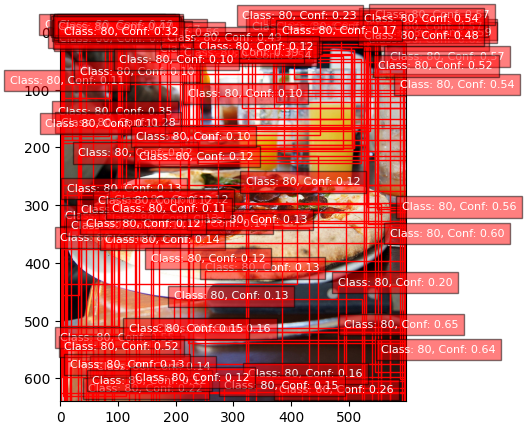

In [117]:
# Assuming coco_evaluator has the necessary attributes
img_id = str(coco_evaluator.img_ids[0].item())[4:]
predictions = [line for line in coco_evaluator.lines if line.split()[0] == img_id]
class_ids = [coco_evaluator.lines_cls[i] for i, line in enumerate(coco_evaluator.lines) if line.split()[0] == img_id]

# Load the image (assuming a function get_image_by_id exists)
image = get_image_by_id(img_id)

# Create a plot
fig, ax = plt.subplots(1)
ax.imshow(image)

# Plot each prediction
for pred, class_id in zip(predictions, class_ids):
    img_id = pred.split()[0]
    confidence = float(pred.split()[1])
    x, y, width, height = [float(x) for x in pred.split()[2:]]
    
    rect = patches.Rectangle((x, y), width, height, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    plt.text(x, y, f'Class: {class_id}, Conf: {confidence:.2f}', color='white', fontsize=8, bbox=dict(facecolor='red', alpha=0.5))

plt.show()

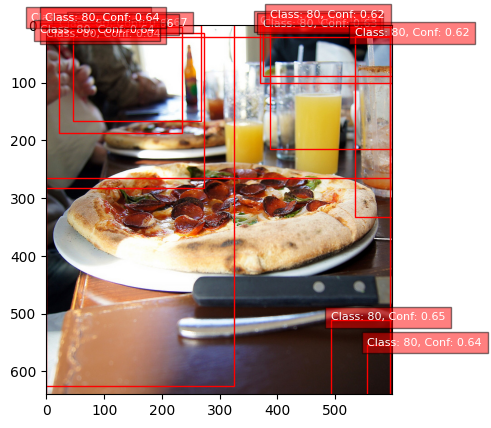

In [134]:
# Assuming coco_evaluator has the necessary attributes
img_id = str(coco_evaluator.img_ids[0].item())[4:]
predictions = [line for line in coco_evaluator.lines if line.split()[0] == img_id]
class_ids = [coco_evaluator.lines_cls[i] for i, line in enumerate(coco_evaluator.lines) if line.split()[0] == img_id]

# Load the image (assuming a function get_image_by_id exists)
image = get_image_by_id(img_id)

# Create a plot
fig, ax = plt.subplots(1)
ax.imshow(image)

# Top 10 confident predictions
sorted_confidences = [float(pred.split()[1]) for pred in predictions]
sorted_confidences.sort(reverse=True)
conf_threshold = sorted_confidences[10]

# Plot each prediction
for pred, class_id in zip(predictions, class_ids):
    img_id = pred.split()[0]
    confidence = float(pred.split()[1])
    x, y, width, height = [float(x) for x in pred.split()[2:]]
    
    if confidence < conf_threshold:
        continue
    
    rect = patches.Rectangle((x, y), width, height, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    plt.text(x, y, f'Class: {class_id}, Conf: {confidence:.2f}', color='white', fontsize=8, bbox=dict(facecolor='red', alpha=0.5))

plt.show()